# Nama : Gibran Wicaksono

# Deteksi Fraud Transaksi Kartu Kredit Menggunakan Autoencoder

## Deskripsi Proyek
Proyek ini bertujuan untuk mendeteksi transaksi kartu kredit yang terindikasi fraud menggunakan metode Autoencoder.

Autoencoder merupakan salah satu metode Deep Learning yang bekerja dengan cara mempelajari pola data normal, kemudian merekonstruksi kembali data tersebut. Jika terdapat data yang berbeda secara signifikan dari pola yang dipelajari, maka akan menghasilkan reconstruction error yang tinggi dan dapat dikategorikan sebagai anomali atau fraud.

Dataset yang digunakan berisi informasi transaksi kartu kredit seperti jumlah transaksi, jenis transaksi, lokasi transaksi, dan status fraud.

In [1]:
!pip install tensorflow pandas numpy matplotlib scikit-learn


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import Library

Pada tahap ini dilakukan import library yang diperlukan untuk proses pengolahan data, pembangunan model Autoencoder, visualisasi data, serta evaluasi model.

In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt

## Membaca Dataset

Dataset dibaca menggunakan library Pandas dan disimpan ke dalam DataFrame untuk memudahkan proses analisis dan pengolahan data.

In [3]:
df = pd.read_csv("C:\\UAS Machine Learning\\credit_card_fraud_dataset.csv")

df.head()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0


In [4]:
print("Jumlah Data :", df.shape)
print("\nInformasi Dataset")
print(df.info())

Jumlah Data : (100000, 7)

Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TransactionID    100000 non-null  int64  
 1   TransactionDate  100000 non-null  object 
 2   Amount           100000 non-null  float64
 3   MerchantID       100000 non-null  int64  
 4   TransactionType  100000 non-null  object 
 5   Location         100000 non-null  object 
 6   IsFraud          100000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 5.3+ MB
None


## Analisis Awal Dataset

Tahap ini bertujuan untuk mengetahui jumlah transaksi normal dan transaksi fraud yang terdapat dalam dataset.

In [5]:
df['IsFraud'].value_counts()

IsFraud
0    99000
1     1000
Name: count, dtype: int64

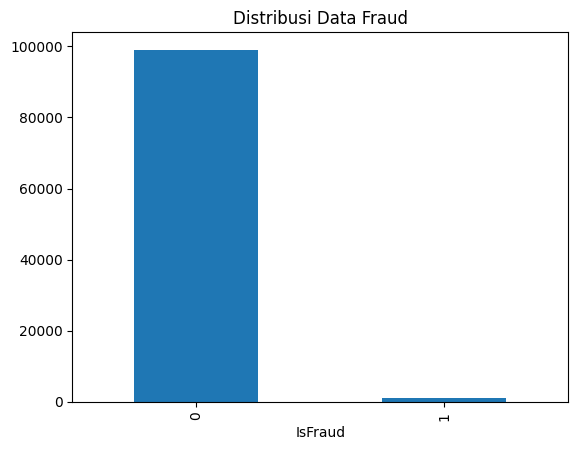

In [6]:
df['IsFraud'].value_counts().plot(
    kind='bar'
)

plt.title("Distribusi Data Fraud")
plt.show()

## Preprocessing Data

Tahap preprocessing dilakukan untuk membersihkan dan menyiapkan data sebelum digunakan dalam proses pelatihan model.

Kolom TransactionID dan TransactionDate tidak digunakan karena tidak memberikan kontribusi langsung terhadap deteksi fraud.

In [7]:
df = df.drop(
    ['TransactionID','TransactionDate'],
    axis=1
)

df.head()

,Amount,MerchantID,TransactionType,Location,IsFraud
0,4189.27,688,refund,San Antonio,0
1,2659.71,109,refund,Dallas,0
2,784.00,394,purchase,New York,0
3,3514.40,944,purchase,Philadelphia,0
4,369.07,475,purchase,Phoenix,0


## Encoding Data Kategorikal

Autoencoder hanya dapat memproses data numerik. Oleh karena itu, atribut kategorikal seperti TransactionType dan Location perlu dikonversi menjadi bentuk numerik menggunakan LabelEncoder.

In [8]:
le_type = LabelEncoder()
le_location = LabelEncoder()

df['TransactionType'] = le_type.fit_transform(
    df['TransactionType']
)

df['Location'] = le_location.fit_transform(
    df['Location']
)

df.head()

,Amount,MerchantID,TransactionType,Location,IsFraud
0,4189.27,688,1,7,0
1,2659.71,109,1,1,0
2,784.00,394,0,4,0
3,3514.40,944,0,5,0
4,369.07,475,0,6,0


## Pemisahan Fitur dan Label

Fitur digunakan sebagai input model, sedangkan label digunakan untuk evaluasi hasil deteksi fraud.

In [9]:
X = df.drop('IsFraud', axis=1)

y = df['IsFraud']

## Normalisasi Data

Normalisasi dilakukan menggunakan MinMaxScaler agar seluruh fitur berada pada rentang 0 hingga 1.

Hal ini membantu Autoencoder dalam proses pembelajaran.

In [10]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

## Pemisahan Data Normal

Autoencoder akan dilatih hanya menggunakan transaksi normal.

Tujuannya agar model dapat mempelajari pola transaksi yang wajar dan mengenali transaksi yang menyimpang sebagai anomali.

In [21]:
X_train = X_scaled[y == 0]

print(X_train.shape)

(99000, 4)


## Membangun Arsitektur Autoencoder

Autoencoder terdiri dari dua bagian utama:

1. Encoder
   - Mengompresi data menjadi representasi yang lebih kecil.

2. Decoder
   - Merekonstruksi kembali data ke bentuk semula.

Loss function yang digunakan adalah Mean Squared Error (MSE).

In [12]:
input_dim = X_train.shape[1]

input_layer = Input(
    shape=(input_dim,)
)

encoder = Dense(
    8,
    activation='relu'
)(input_layer)

encoder = Dense(
    4,
    activation='relu'
)(encoder)

decoder = Dense(
    8,
    activation='relu'
)(encoder)

decoder = Dense(
    input_dim,
    activation='sigmoid'
)(decoder)

autoencoder = Model(
    inputs=input_layer,
    outputs=decoder
)

autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152 (608.00 B)

 Trainable params: 152 (608.00 B)

 Non-trainable params: 0 (0.00 B)

## Pelatihan Model

Model dilatih menggunakan data transaksi normal selama beberapa epoch.

Tujuan pelatihan adalah meminimalkan nilai reconstruction error.

In [13]:
history = autoencoder.fit(
    X_train,
    X_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0929 - val_loss: 0.0429
Epoch 2/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0198 - val_loss: 0.0117
Epoch 3/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0064 - val_loss: 0.0024
Epoch 4/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0015 - val_loss: 0.0011
Epoch 5/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9.9704e-04 - val_loss: 9.3283e-04
Epoch 6/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.9713e-04 - val_loss: 8.7219e-04
Epoch 7/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.5673e-04 - val_loss: 8.4555e-04
Epoch 8/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.3531e-04 - val_loss: 8.4152e-04
Epoch 9/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.2286e-04 - val_loss: 8.2078e-04
Epoch 10/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.1607e-04 - val_loss: 8.2428e-04
Epoch 11/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.0989e-04 - val_loss: 8.0699e

## Visualisasi Loss

Grafik loss digunakan untuk melihat perkembangan proses pelatihan model.

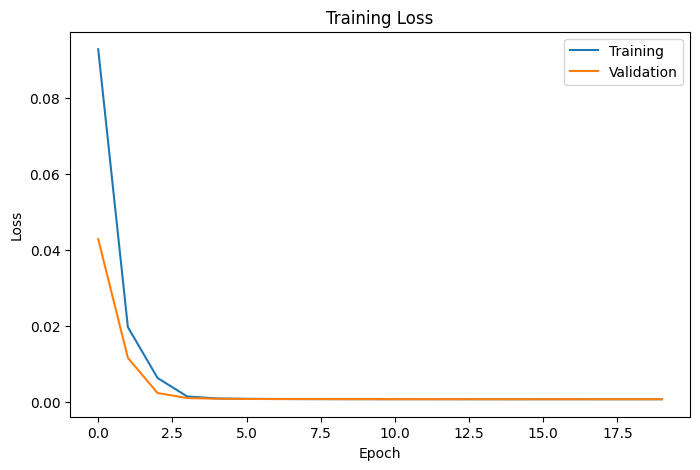

In [14]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss']
)

plt.plot(
    history.history['val_loss']
)

plt.title(
    'Training Loss'
)

plt.xlabel(
    'Epoch'
)

plt.ylabel(
    'Loss'
)

plt.legend(
    ['Training','Validation']
)

plt.show()

## Menghitung Reconstruction Error

Setelah model selesai dilatih, dilakukan proses rekonstruksi terhadap seluruh data.

Selisih antara data asli dan hasil rekonstruksi dihitung menggunakan Mean Squared Error (MSE).

In [15]:
reconstruction = autoencoder.predict(
    X_scaled
)

mse = np.mean(
    np.power(
        X_scaled - reconstruction,
        2
    ),
    axis=1
)

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step


## Menentukan Threshold

Threshold digunakan sebagai batas untuk membedakan transaksi normal dan transaksi fraud.

Pada penelitian ini digunakan persentil ke-95 dari nilai reconstruction error.

In [16]:
threshold = np.percentile(
    mse,
    95
)

print(
    "Threshold :",
    threshold
)

Threshold : 0.0019115461606829254


## Prediksi Fraud

Jika nilai reconstruction error melebihi threshold, maka transaksi dikategorikan sebagai fraud.

In [17]:
predictions = (
    mse > threshold
).astype(int)

## Evaluasi Model

Evaluasi dilakukan menggunakan Confusion Matrix dan Classification Report untuk mengetahui performa model dalam mendeteksi transaksi fraud.

In [18]:
cm = confusion_matrix(
    y,
    predictions
)

print(cm)

[[94053  4947]
 [  947    53]]


In [19]:
print(
    classification_report(
        y,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.99      0.95      0.97     99000
           1       0.01      0.05      0.02      1000

    accuracy                           0.94    100000
   macro avg       0.50      0.50      0.49    100000
weighted avg       0.98      0.94      0.96    100000



# Kesimpulan

Model Autoencoder berhasil digunakan untuk mendeteksi transaksi fraud berdasarkan reconstruction error.

Autoencoder mempelajari pola transaksi normal dan mengidentifikasi transaksi yang memiliki karakteristik berbeda sebagai anomali.

Semakin besar reconstruction error yang dihasilkan, semakin besar kemungkinan transaksi tersebut merupakan fraud.